# ChemVL Grad-CAM Visualization Demo (CLI)

This notebook runs **upstream (descriptor) Grad-CAM** and **downstream (fine-tuned task) Grad-CAM** via the Tier-1 CLI [`interpret.py`](../interpret.py).

We keep the original narrative (Fig.4a descriptor prompts; Fig.4b downstream contexts) but execute one preset-driven run and display the resulting composite panels.

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name == "notebooks":
    sys.path.insert(0, str(NOTEBOOK_DIR))
else:
    sys.path.insert(0, str(NOTEBOOK_DIR / "notebooks"))

from _notebook_utils import repo_root, data_root, configure_chemvl_data_root, configure_quiet_demo_logging, ensure_repo_on_path, run_cmd, assert_paths_exist, display_pngs

ROOT = ensure_repo_on_path()
configure_chemvl_data_root()
configure_quiet_demo_logging()
DATA = data_root()
PRESET = ROOT / "notebooks/presets/b_case_moleculenet_notebook.yaml"
OUTPUT_DIR = ROOT / "results/notebooks/b_gradcam"

assert_paths_exist([
    DATA / "checkpoints/pretraining/RN50px224.ckpt",
    DATA / "checkpoints/finetuning/presets/knowledge_prompt_tuning/bbbp/ckpt.pth",
    DATA / "checkpoints/finetuning/presets/knowledge_prompt_tuning/bace/ckpt.pth",
], label="Grad-CAM checkpoints")

print("Repo root:", ROOT)
print("Preset:", PRESET)
print("Output:", OUTPUT_DIR)

Repo root: /home/yhuang/projects/ChemVL-public-staging
Preset: /home/yhuang/projects/ChemVL-public-staging/notebooks/presets/b_case_moleculenet_notebook.yaml
Output: /home/yhuang/projects/ChemVL-public-staging/results/notebooks/b_gradcam


## Visual attention for pre-training

### Global settings

Run the full case panel once. Each PNG row shows:
**structure | NumAromaticRings | fr_benzene | NOCount | fr_halogen | downstream**

The markdown subsections below refer to **columns** in this panel (same molecules as the legacy notebook).

$ /home/yhuang/miniconda3/envs/chemvl/bin/python /home/yhuang/projects/ChemVL-public-staging/interpret.py visual run --preset /home/yhuang/projects/ChemVL-public-staging/notebooks/presets/b_case_moleculenet_notebook.yaml --output-dir /home/yhuang/projects/ChemVL-public-staging/results/notebooks/b_gradcam


Load knowledge memory from /mnt/d/wsl-data/chemvl/cache_for_knowledge/bbbp_knowledge_memory_v2_107-base.pkl.
Load knowledge memory from /mnt/d/wsl-data/chemvl/cache_for_knowledge/bace_knowledge_memory_v2_107-base.pkl.
Wrote 4 figure(s) to /home/yhuang/projects/ChemVL-public-staging/results/notebooks/b_gradcam


Manifest: /home/yhuang/projects/ChemVL-public-staging/results/notebooks/b_gradcam/manifest.json
3ivi_gradcam_panel.png


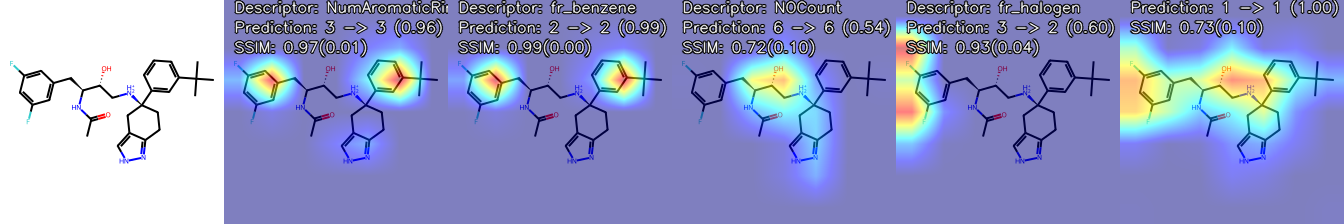

CHEMBL1092788_gradcam_panel.png


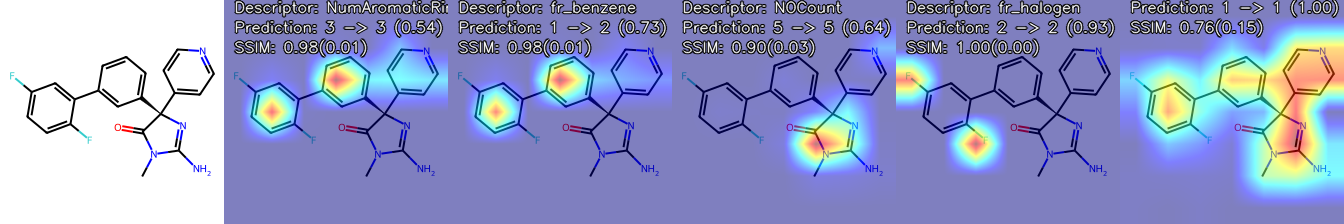

Cebaracetam_gradcam_panel.png


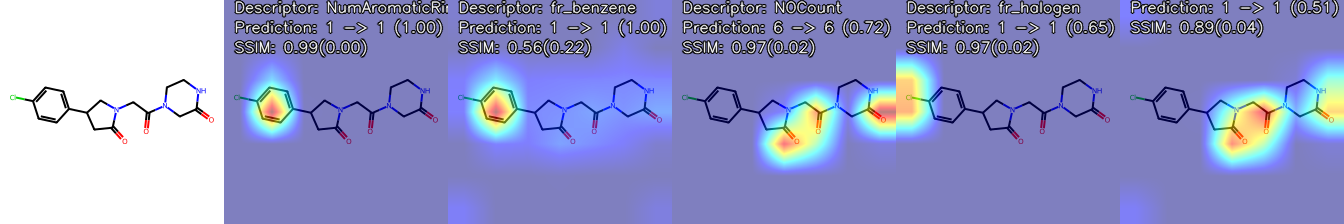

Dinazafone_gradcam_panel.png


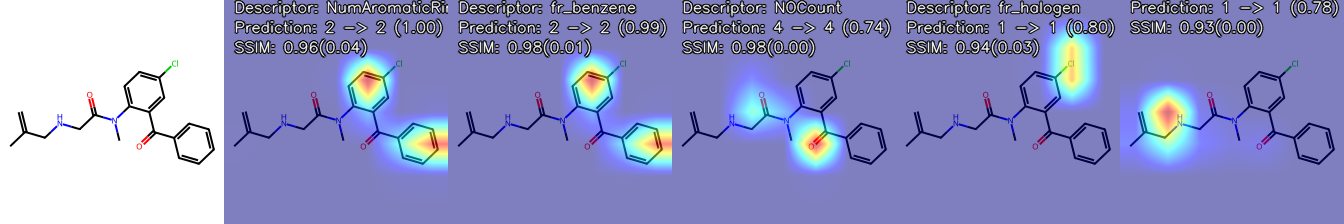

In [2]:
cmd = [
    sys.executable,
    str(ROOT / "interpret.py"),
    "visual", "run",
    "--preset", str(PRESET),
    "--output-dir", str(OUTPUT_DIR),
]
run_cmd(cmd, cwd=ROOT)
print("Manifest:", OUTPUT_DIR / "manifest.json")
display_pngs(OUTPUT_DIR, "*_gradcam_panel.png")

### Sample molecules anchored by different molecular descriptor-based prompts

Representative cases (Fig.4a): Cebaracetam, Dinazafone, 3IVI, CHEMBL1092788.

#### Aromatic Rings (`NumAromaticRings`)

Inspect the **second column** (after structure) in each panel above.

Cebaracetam_gradcam_panel.png


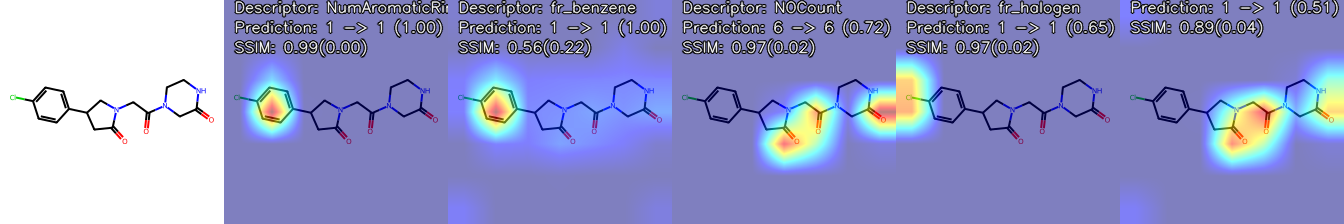

Dinazafone_gradcam_panel.png


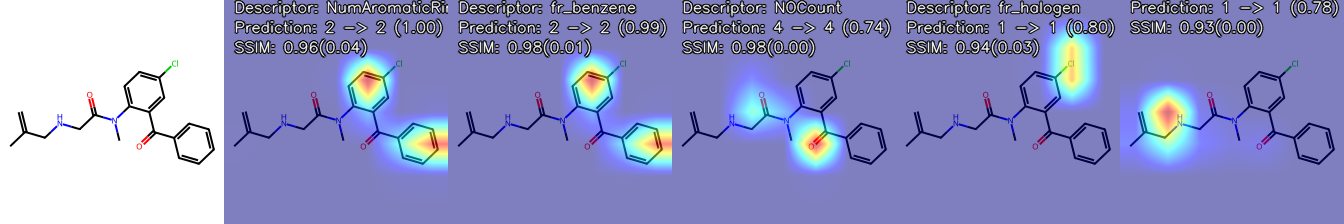

3ivi_gradcam_panel.png


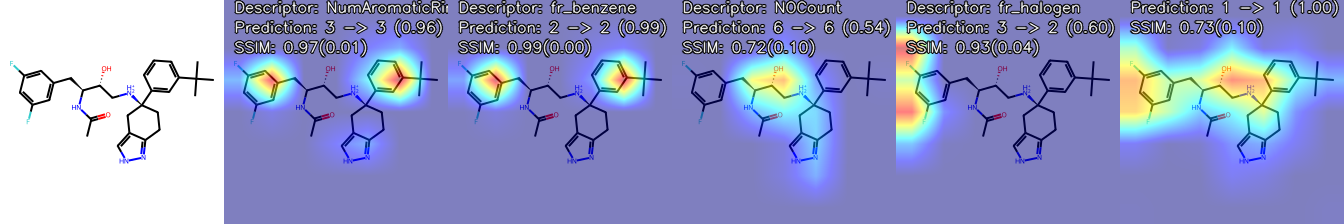

CHEMBL1092788_gradcam_panel.png


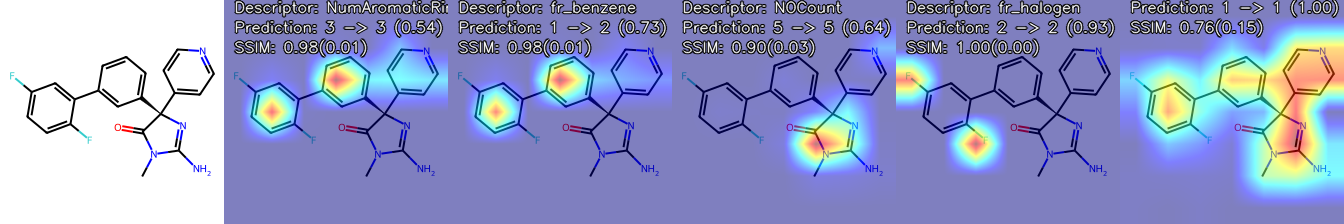

In [3]:
display_pngs(OUTPUT_DIR, "Cebaracetam_gradcam_panel.png")
display_pngs(OUTPUT_DIR, "Dinazafone_gradcam_panel.png")
display_pngs(OUTPUT_DIR, "3ivi_gradcam_panel.png")
display_pngs(OUTPUT_DIR, "CHEMBL1092788_gradcam_panel.png")

#### Benzene (`fr_benzene`)

Inspect the **third column** in each panel.

#### NOCount

Inspect the **fourth column** in each panel.

#### Halogen (`fr_halogen`)

Inspect the **fifth column** in each panel.

## Visual attention for downstream tasks

The **last column** in each panel is the finetuned-task Grad-CAM (BBBP or BACE depending on the case).

### BBBP (Cebaracetam & Dinazafone)

Cebaracetam_gradcam_panel.png


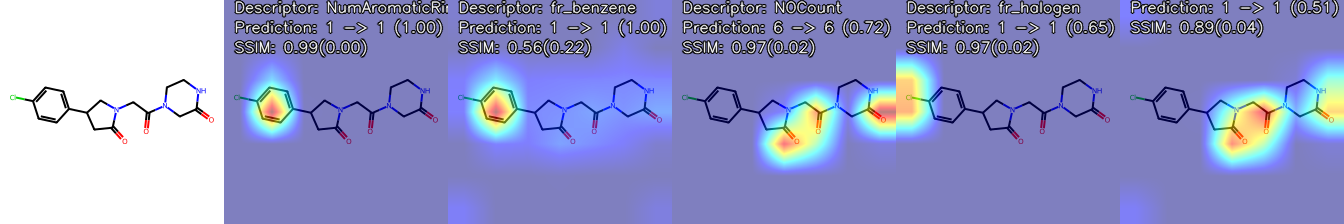

Dinazafone_gradcam_panel.png


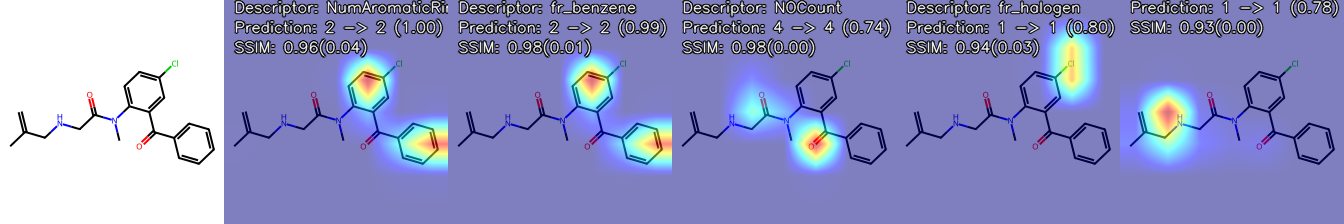

In [4]:
for case in ("Cebaracetam", "Dinazafone"):
    display_pngs(OUTPUT_DIR, f"{case}_gradcam_panel.png")

### BACE (3IVI & CHEMBL1092788)

3ivi_gradcam_panel.png


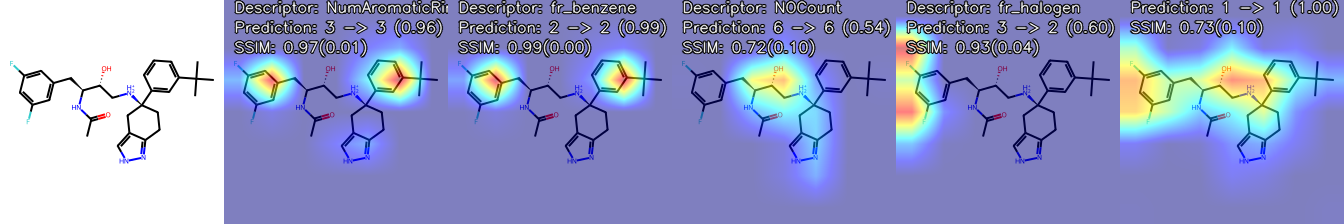

CHEMBL1092788_gradcam_panel.png


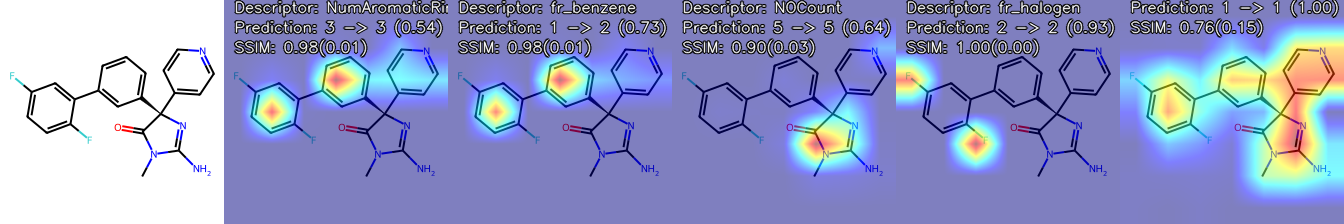

In [5]:
for case in ("3ivi", "CHEMBL1092788"):
    display_pngs(OUTPUT_DIR, f"{case}_gradcam_panel.png")

### Run a single case via CLI (optional)

```bash
python interpret.py visual run \
  --preset notebooks/presets/b_case_moleculenet_notebook.yaml \
  --case Cebaracetam \
  --output-dir results/notebooks/b_gradcam_cebaracetam
```

In [6]:
# Optional: single-case rerun
# run_cmd([
#     sys.executable, str(ROOT / "interpret.py"), "visual", "run",
#     "--preset", str(PRESET), "--case", "Cebaracetam",
#     "--output-dir", str(ROOT / "results/notebooks/b_gradcam_cebaracetam"),
# ], cwd=ROOT)